In [9]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
from pyspark.sql import functions as F
import time
from pyspark.sql.functions import col, when, to_date, year, month, dayofmonth, trim, lower, round as spark_round,avg,count
import matplotlib.pyplot as plt
import numpy as np

In [10]:
import time
import os
import shutil
from pyspark.sql import SparkSession

# ============================================
# SETUP
# ============================================
try:
    spark.stop()
except:
    pass

spark = SparkSession.builder \
    .appName("CSV vs Parquet") \
    .master("local[4]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.default.parallelism", "8") \
    .getOrCreate()

# Verify configuration
print(f"Driver Memory: {spark.conf.get('spark.driver.memory')}")
print(f"Shuffle Partitions: {spark.conf.get('spark.sql.shuffle.partitions')}")
print(f"Master URL: {spark.conf.get('spark.master')}")


Driver Memory: 8g
Shuffle Partitions: 8
Master URL: local[4]


In [11]:
df2 = spark.read.parquet("data/features/")

In [12]:
train_df, test_df = df2.randomSplit([0.8, 0.2], seed=42)

# Cache both — they'll be reused many times during CV
train_df.cache()
test_df.cache()

DataFrame[features_selected: vector, label_index: double, Label: string]

In [13]:
from pyspark.ml.classification import RandomForestClassifier  # or whatever model
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

model = RandomForestClassifier(
    featuresCol="features_selected",
    labelCol="label_index",
    seed=42
)

paramGrid = (
    ParamGridBuilder()
    .addGrid(model.numTrees, [50, 100])
    .addGrid(model.maxDepth, [5, 10])
    .build()
)

evaluator = MulticlassClassificationEvaluator(
    labelCol="label_index",
    predictionCol="prediction",
    metricName="f1"          # f1 is better than accuracy for imbalanced-origin data
)

cv = CrossValidator(
    estimator=model,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,              # 5 if you have time, 3 is safer in Spark
    seed=42
)

cv_model = cv.fit(train_df)  # only train_df, never test_df

f1: 0.9816
accuracy: 0.9817
weightedPrecision: 0.9821
weightedRecall: 0.9817


/usr/local/spark/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


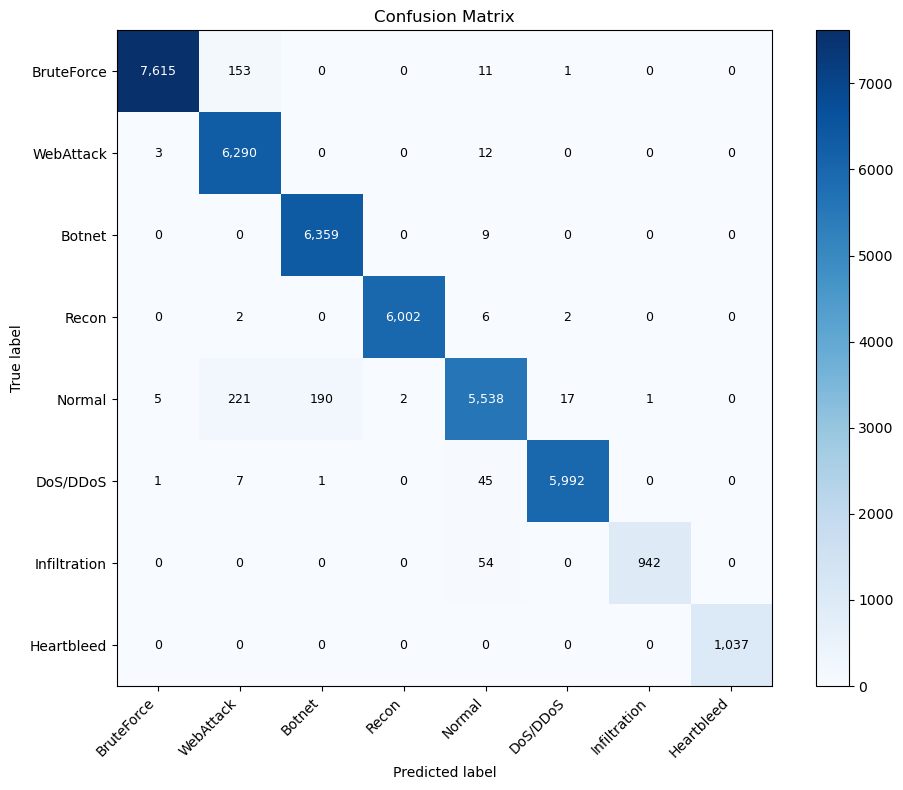

In [14]:
from pyspark.mllib.evaluation import MulticlassMetrics
import matplotlib.pyplot as plt
import numpy as np

predictions = cv_model.transform(test_df)

# Metrics
for metric in ["f1", "accuracy", "weightedPrecision", "weightedRecall"]:
    score = evaluator.evaluate(predictions, {evaluator.metricName: metric})
    print(f"{metric}: {score:.4f}")

# Confusion matrix
preds_and_labels = predictions.select("prediction", "label_index") \
    .rdd.map(lambda r: (float(r["prediction"]), float(r["label_index"])))

metrics = MulticlassMetrics(preds_and_labels)
labels  = sorted(predictions.select("label_index").distinct().rdd.map(lambda r: float(r[0])).collect())
cm      = np.array([[metrics.confusionMatrix().toArray()[int(i)][int(j)] for j in labels] for i in labels])

# ── Recover label names from test_df (has both columns before transform) ──
label_map = {
    float(r["label_index"]): r["label"]
    for r in test_df.select("label", "label_index").distinct().collect()
}
label_names = [label_map[i] for i in labels]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(len(label_names)),
    yticks=np.arange(len(label_names)),
    xticklabels=label_names,
    yticklabels=label_names,
    xlabel="Predicted label",
    ylabel="True label",
    title="Confusion Matrix"
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Annotate cells
thresh = cm.max() / 2.0
for i in range(len(label_names)):
    for j in range(len(label_names)):
        ax.text(j, i, f"{int(cm[i, j]):,}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=9)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [17]:
from xgboost.spark import SparkXGBClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

xgb = SparkXGBClassifier(
    features_col="features_selected",
    label_col="label_index",
    num_workers=4,
    seed=42
)

xgb_grid = (
    ParamGridBuilder()
    .addGrid(xgb.max_depth, [5, 10])
    .addGrid(xgb.n_estimators, [50, 100])
    .build()
)

cv_xgb = CrossValidator(
    estimator=xgb,
    estimatorParamMaps=xgb_grid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

xgb_model = cv_xgb.fit(train_df)
xgb_preds = xgb_model.transform(test_df)

INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 4 workers with
	booster params: {'device': 'cpu', 'max_depth': 5, 'objective': 'multi:softprob', 'seed': 42, 'num_class': 8, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 50}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!
INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 4 workers with
	booster params: {'device': 'cpu', 'max_depth': 5, 'objective': 'multi:softprob', 'seed': 42, 'num_class': 8, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!
INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 4 workers with
	booster params: {'device': 'cpu', 'max_depth': 10, 'objective': 'multi:softprob', 'seed': 42, 'num_class': 8, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 50}
	dmatrix_kwargs: {'nthread': 1, 

In [18]:
for m in ["f1", "accuracy", "weightedPrecision", "weightedRecall"]:
    score = evaluator.evaluate(xgb_preds, {evaluator.metricName: m})
    print(f"{m}: {score:.4f}")

f1: 0.9867
accuracy: 0.9868
weightedPrecision: 0.9870
weightedRecall: 0.9868


In [19]:
from pyspark.mllib.evaluation import MulticlassMetrics
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion(predictions, title="Confusion Matrix"):
    preds_and_labels = predictions.select("prediction", "label_index") \
        .rdd.map(lambda r: (float(r["prediction"]), float(r["label_index"])))

    metrics = MulticlassMetrics(preds_and_labels)

    labels = sorted(
        predictions.select("label_index")
        .distinct()
        .rdd.map(lambda r: float(r[0]))
        .collect()
    )

    cm = metrics.confusionMatrix().toArray()

    # ✅ FIX: use "Label"
    label_map = {
        float(r["label_index"]): r["Label"]
        for r in predictions.select("Label", "label_index").distinct().collect()
    }

    label_names = [label_map[i] for i in labels]

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(label_names)),
        yticks=np.arange(len(label_names)),
        xticklabels=label_names,
        yticklabels=label_names,
        xlabel="Predicted label",
        ylabel="True label",
        title=title
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    thresh = cm.max() / 2.0
    for i in range(len(label_names)):
        for j in range(len(label_names)):
            ax.text(
                j, i, f"{int(cm[i, j]):,}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

/usr/local/spark/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


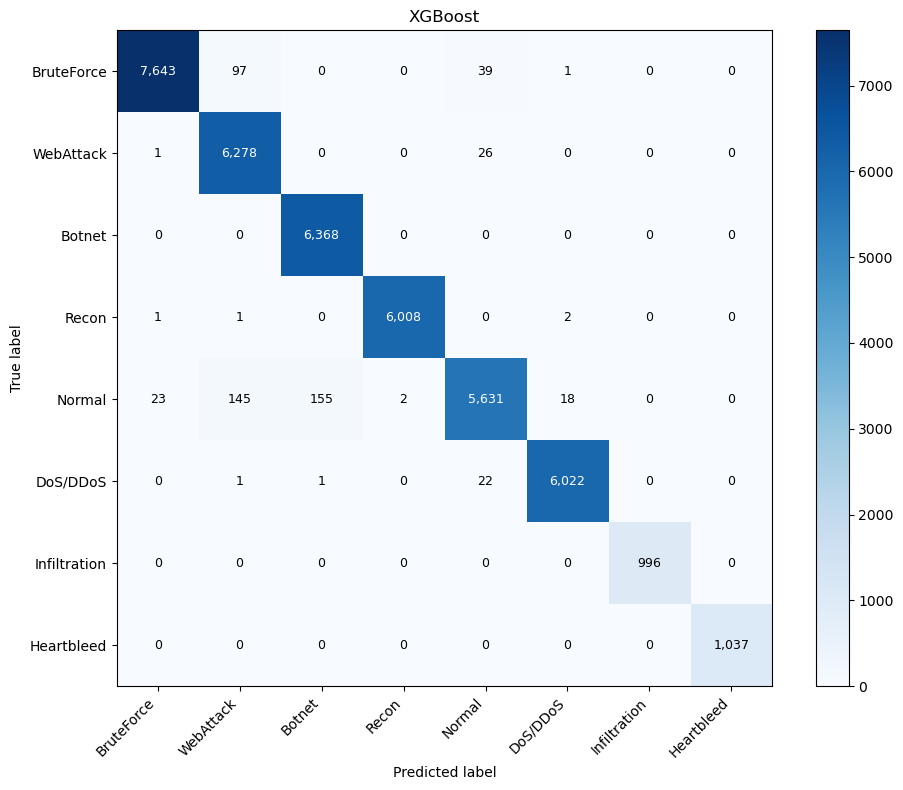

In [20]:
plot_confusion(xgb_preds, "XGBoost")

In [21]:
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.tuning import ParamGridBuilder

input_size = len(train_df.select("features_selected").first()[0])
num_classes = train_df.select("label_index").distinct().count()

mlp = MultilayerPerceptronClassifier(
    featuresCol="features_selected",
    labelCol="label_index",
    layers=[input_size, 64, 32, num_classes],
    seed=42,
    maxIter=100
)

mlp_grid = (
    ParamGridBuilder()
    .addGrid(mlp.stepSize, [0.01, 0.1])
    .addGrid(mlp.maxIter, [50, 100])
    .build()
)

cv_mlp = CrossValidator(
    estimator=mlp,
    estimatorParamMaps=mlp_grid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

mlp_model = cv_mlp.fit(train_df)
mlp_preds = mlp_model.transform(test_df)

In [22]:
for m in ["f1", "accuracy", "weightedPrecision", "weightedRecall"]:
    score = evaluator.evaluate(mlp_preds, {evaluator.metricName: m})
    print(f"{m}: {score:.4f}")

f1: 0.9531
accuracy: 0.9535
weightedPrecision: 0.9537
weightedRecall: 0.9535


/usr/local/spark/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


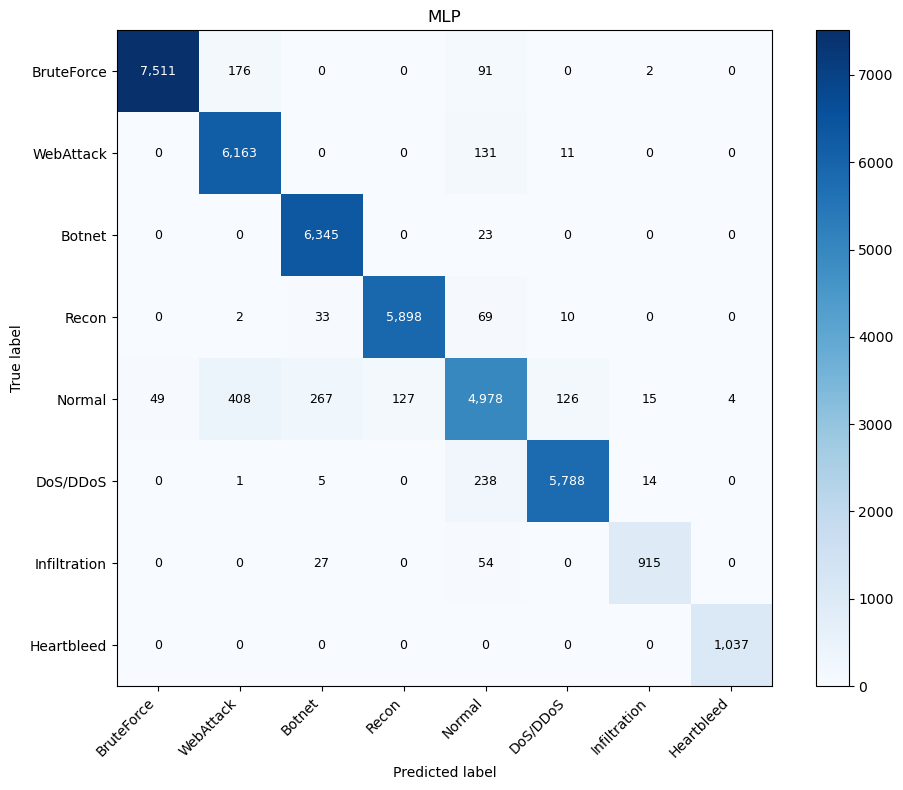

In [23]:
plot_confusion(mlp_preds, "MLP")

In [28]:
import pandas as pd

models = {
    "Random Forest": predictions,
    "XGBoost": xgb_preds,
    "MLP": mlp_preds
}

metrics_list = ["f1", "accuracy", "weightedPrecision", "weightedRecall"]

results = []

for model_name, preds in models.items():
    row = {"model": model_name}
    
    for metric in metrics_list:
        score = evaluator.evaluate(preds, {evaluator.metricName: metric})
        row[metric] = score
    
    results.append(row)

df_results = pd.DataFrame(results)
print(df_results)

           model        f1  accuracy  weightedPrecision  weightedRecall
0  Random Forest  0.981612  0.981662           0.982128        0.981662
1        XGBoost  0.986745  0.986796           0.986983        0.986796
2            MLP  0.953135  0.953527           0.953680        0.953527


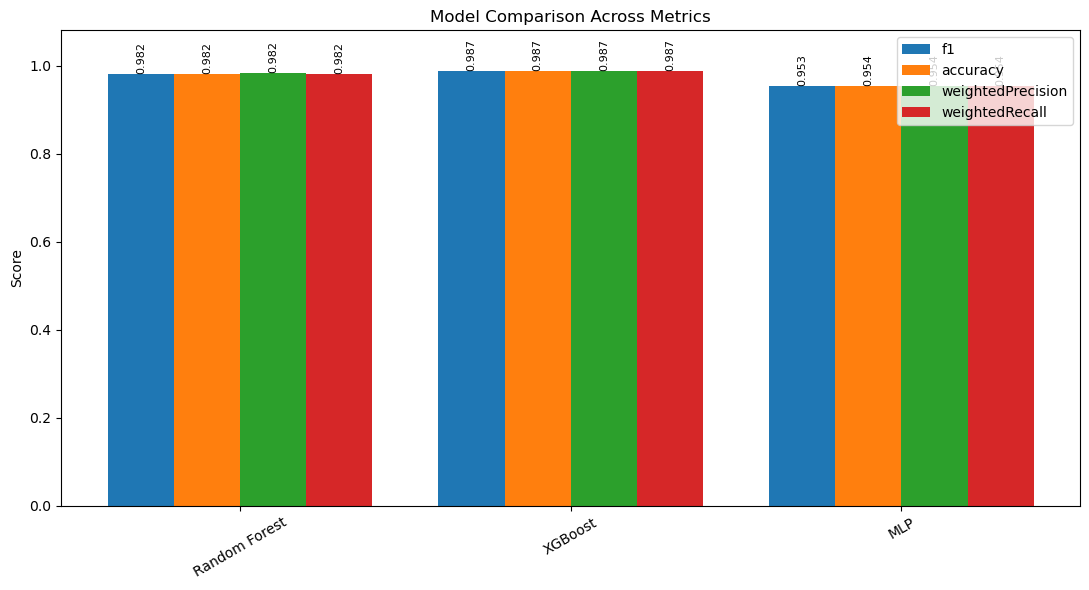

In [32]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["f1", "accuracy", "weightedPrecision", "weightedRecall"]

models = df_results["model"]
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(11, 6))

bars = []

for i, m in enumerate(metrics):
    bar = plt.bar(
        x + i * width,
        df_results[m],
        width,
        label=m
    )
    bars.append((bar, m))

    # ✨ Add value labels
    for rect in bar:
        height = rect.get_height()
        plt.text(
            rect.get_x() + rect.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(x + width * 1.5, models, rotation=30)
plt.ylim(0, 1.08)
plt.legend()
plt.tight_layout()

plt.show()

In [33]:
spark.stop()